
# Redes Neuronales con PyTorch — Diferenciación Automática y Cálculo de Gradientes




Un **tensor** es un arreglo multi-dimensional. Por ejemplo:

* 400x400 - imagen en blanco y negro
* 400x400x3 - imagen a color
* 16x400x400x3 - minibatch 16 imagenes a color
* 25x400x400x3 - un segundo de un video a 25 FPS
* 8x25x400x400x3 - minibatch de 8 videos de 1 segundo


In [12]:

# (Opcional) Comprobación rápida
import sys, torch, matplotlib
print("Python:", sys.version.split()[0])
print("PyTorch:", torch.__version__)
print("CUDA disponible:", torch.cuda.is_available())
print("Matplotlib:", matplotlib.__version__)
device = "cuda" if torch.cuda.is_available() else "cpu"
device


Python: 3.12.3
PyTorch: 2.3.0
CUDA disponible: False
Matplotlib: 3.9.0


'cpu'


## 1. Fundamentos de `autograd`

En PyTorch, los tensores pueden llevar una "bandera" `requires_grad=True`.  
Cualquier operación sobre ellos queda registrada en un **grafo computacional** dirigido.  
Cuando llamamos a `.backward()`, PyTorch recorre ese grafo **en sentido inverso** y acumula gradientes en `tensor.grad`  
para todos los tensores hoja (normalmente, los **parámetros**) que requieren gradiente.

Conceptos clave:
- `requires_grad`: activa el seguimiento para el tensor.
- `grad_fn`: función que creó el tensor (nodo en el grafo).
- `backward()`: propaga el gradiente hasta las hojas.
- **Acumulación**: los gradientes **se acumulan** en `param.grad`; usa `optimizer.zero_grad()` o `param.grad.zero_()` para limpiarlos.
- `with torch.no_grad():` desactiva el seguimiento (útil en evaluación/actualización manual).
- `tensor.detach()`: obtiene una vista sin gradientes.


In [14]:
import torch

# Escenario simple: y = (w*x + b)^2
x = torch.tensor([2.0], requires_grad=False)
w = torch.tensor([3.0], requires_grad=True)
b = torch.tensor([1.0], requires_grad=True)
y = (w * x + b)**2
print("y:", y.item())
print("grad_fn de y:", y.grad_fn)
# Backprop
y.backward()  # dy/dw y dy/db
print("dy/dw:", w.grad.item())
print("dy/db:", b.grad.item())
# Limpieza (muy importante)
w.grad.zero_()
b.grad.zero_()

y: 49.0
grad_fn de y: <PowBackward0 object at 0x123548250>
dy/dw: 28.0
dy/db: 14.0


tensor([0.])

In [15]:
print("evaluacion de y : ",(3*2+1)**2)

evaluacion de y :  49


In [16]:
print("evaluacion de dy/dw : {0}, dy/db : {1}".format(2*(3*2+1)*2, 2*(3*2+1)))

evaluacion de dy/dw : 28, dy/db : 14



### Gradientes de escalares vs. tensores

Si el tensor de salida **no es escalar**, debes suministrar explícitamente el **vector** contra el que proyectar el Jacobiano
(`gradient` en `.backward(gradient=...)`). Abajo un ejemplo con una salida de 2 dimensiones.


In [19]:
a = torch.tensor([2., 3.], requires_grad=True)
b = torch.tensor([6., 4.], requires_grad=True)
Q = 3*a**3 - b**2

Calculamos $\frac{\partial Q}{\partial a}=9a^2$ y $\frac{\partial Q}{\partial b}=2b$ 

In [20]:
external_grad = torch.tensor([1., 1.])
Q.backward(gradient=external_grad)
# check if collected gradients are correct
print(9*a**2 == a.grad)
print(-2*b == b.grad)

tensor([True, True])
tensor([True, True])



## 2. Perpeptron MultiCapa

Implementaremos una red totalmente conectada (1 → 20 → 1) para aproximar una función no lineal.
Mostraremos claramente **dónde** se hace `loss.backward()` y **qué** gradientes se actualizan.


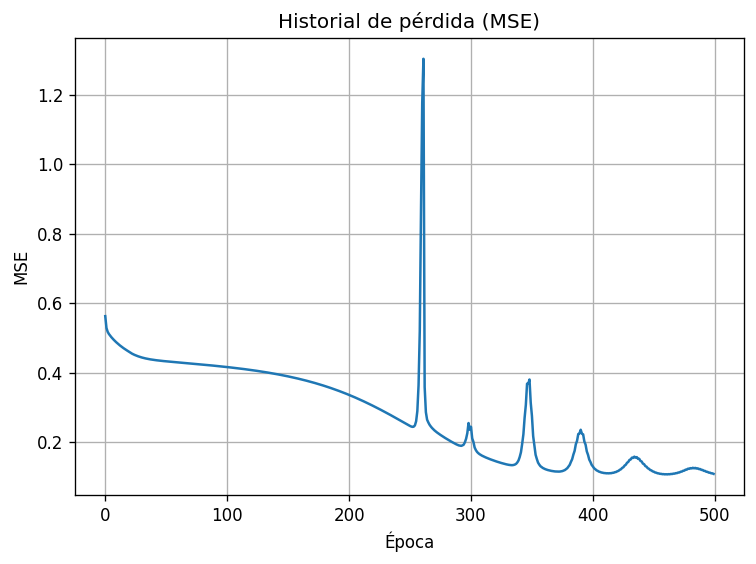

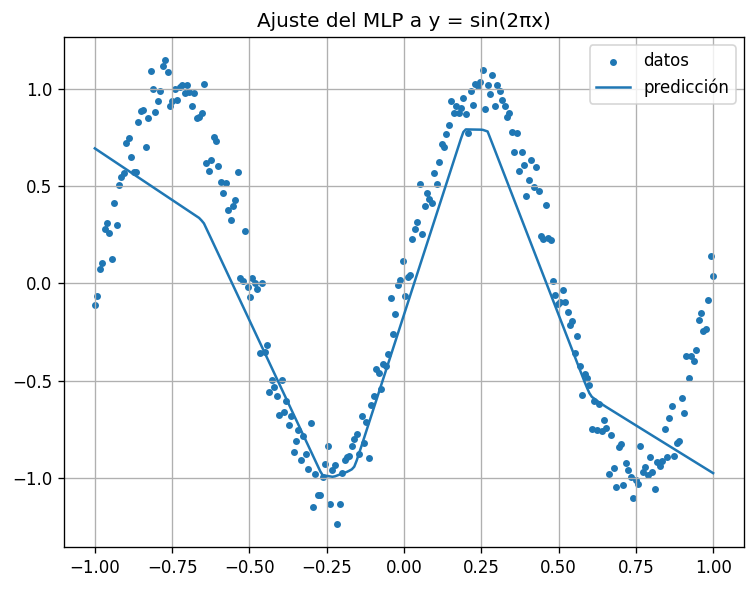

In [32]:

import torch
import torch.nn as nn
import torch.nn.functional as F
import math
import matplotlib.pyplot as plt

torch.manual_seed(0)

# Datos sintéticos: y = sin(2πx) + ruido
n = 256
X = torch.linspace(-1, 1, n).unsqueeze(1)
y = torch.sin(2*math.pi*X) + 0.1*torch.randn_like(X)

class MLP(nn.Module):
    def __init__(self):
        super().__init__()
        self.hidden1 = nn.Linear(1, 20)
        self.hidden2 = nn.Linear(20, 10)
        self.out = nn.Linear(10, 1)
    def forward(self, x):
        x = F.relu(self.hidden1(x))
        x = F.relu(self.hidden2(x))
        return self.out(x)

model = MLP()
optimizer = torch.optim.SGD(model.parameters(), lr=0.1)
loss_fn = nn.MSELoss()

loss_history = []

for epoch in range(500):
    # 1) forward
    pred = model(X)
    loss = loss_fn(pred, y)
    # 2) backward: calcula ∂loss/∂θ y los acumula en θ.grad
    optimizer.zero_grad()
    loss.backward()
    # 3) step: actualiza θ ← θ - lr * grad
    optimizer.step()

    loss_history.append(loss.item())

# Visualización
plt.figure(dpi=120)
plt.plot(loss_history)
plt.title("Historial de pérdida (MSE)")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.grid(True)
plt.tight_layout()
plt.show()

plt.figure(dpi=120)
plt.scatter(X.detach().numpy(), y.detach().numpy(), s=10, label="datos")
plt.plot(X.detach().numpy(), model(X).detach().numpy(), label="predicción")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.title("Ajuste del MLP a y = sin(2πx)")
plt.show()


In [35]:
[p.shape for p in model.parameters()]

[torch.Size([20, 1]),
 torch.Size([20]),
 torch.Size([10, 20]),
 torch.Size([10]),
 torch.Size([1, 10]),
 torch.Size([1])]


### Buenas prácticas con gradientes

- Llama **siempre** a `optimizer.zero_grad()` antes de `loss.backward()` para evitar acumulación no deseada.
- Desactiva gradientes durante la evaluación con `torch.no_grad()`.
- Usa `model.train()` y `model.eval()` para activar/desactivar capas como Dropout/BatchNorm.


In [37]:

# Evaluación sin seguimiento de gradientes
model.eval()
with torch.no_grad():
    preds = model(X)
float(((preds - y)**2).mean())


0.10875984281301498


## 3. Optimizadores y tasa de aprendizaje (LR)

Probemos distintos optimizadores con la **misma arquitectura** y comparemos la pérdida.  
La elección del optimizador y del LR afecta la **velocidad de convergencia** y la **estabilidad** del entrenamiento.


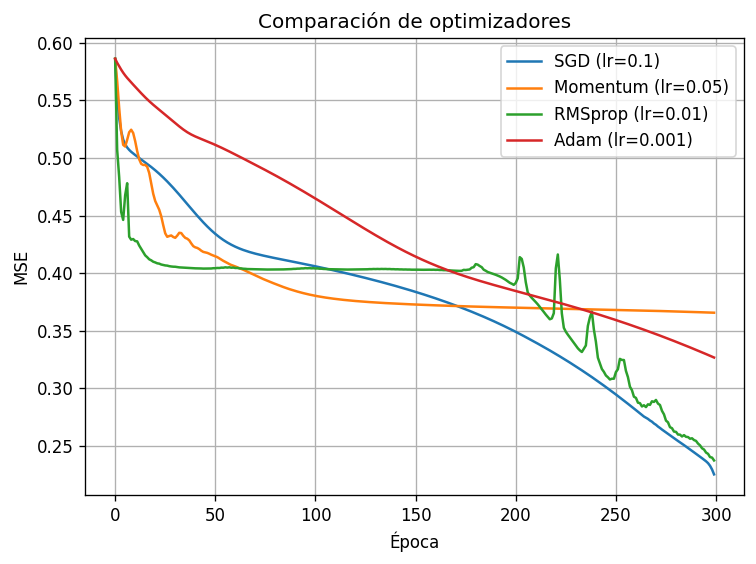

In [40]:

def train_with(optimizer_ctor, lr=0.01, epochs=300):
    torch.manual_seed(0)
    net = MLP()
    opt = optimizer_ctor(net.parameters(), lr=lr)
    losses = []
    for _ in range(epochs):
        pred = net(X)
        loss = loss_fn(pred, y)
        opt.zero_grad()
        loss.backward()
        opt.step()
        losses.append(loss.item())
    return losses

opt_confs = [
    ("SGD", torch.optim.SGD, 0.1),
    ("Momentum", lambda p, lr: torch.optim.SGD(p, lr=lr, momentum=0.9), 0.05),
    ("RMSprop", torch.optim.RMSprop, 0.01),
    ("Adam", torch.optim.Adam, 0.001),
]

plt.figure(dpi=120)
for name, ctor, lr in opt_confs:
    losses = train_with(ctor, lr=lr, epochs=300)
    plt.plot(losses, label=f"{name} (lr={lr})")
plt.legend()
plt.title("Comparación de optimizadores")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.grid(True)
plt.tight_layout()
plt.show()


In [41]:
X.shape

torch.Size([256, 1])


## 4. Tamaño de lote (Batch Size) y `DataLoader`

Para datasets grandes, usa `TensorDataset` + `DataLoader` para **mini-batches**.  
Esto permite calcular gradientes con varias muestras a la vez, estabiliza las actualizaciones y
aprovecha mejor la memoria.


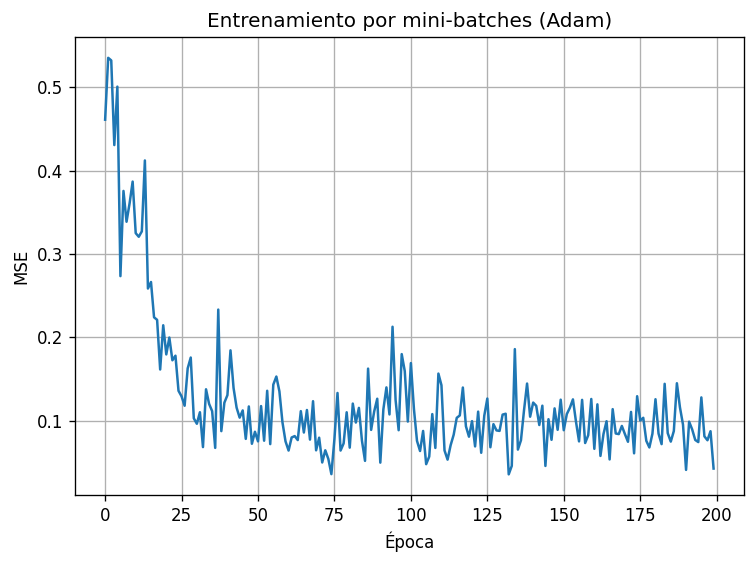

In [43]:

from torch.utils.data import TensorDataset, DataLoader

BATCH_SIZE = 32
dataset = TensorDataset(X, y)
loader = DataLoader(dataset, batch_size=BATCH_SIZE, shuffle=True)

torch.manual_seed(0)
net = MLP()
opt = torch.optim.Adam(net.parameters(), lr=1e-2)
losses = []

for epoch in range(200):
    for xb, yb in loader:
        pred = net(xb)
        loss = loss_fn(pred, yb)
        opt.zero_grad()
        loss.backward()
        opt.step()
    losses.append(loss.item())

plt.figure(dpi=120)
plt.plot(losses)
plt.title("Entrenamiento por mini-batches (Adam)")
plt.xlabel("Época")
plt.ylabel("MSE")
plt.grid(True)
plt.tight_layout()
plt.show()



## 5. Operaciones avanzadas de autograd

PyTorch expone utilidades para obtener **Jacobianos** y **Hessianos** sobre funciones diferenciables.  
Aquí mostramos el **Jacobiano** de una pequeña red con respecto a su entrada.


In [23]:
from torch.autograd.functional import jacobian

F = lambda x : (x[0],5*x[2],4*x[1]**2-2*x[2])

data = [[1, 2,1]]
x_data = torch.tensor(data,requires_grad=True)

J = jacobian(F, x_data)  # forma (3, 3): salida_dim x entrada_dim
print("Jacobiano f(x) en x:\n", J)

RuntimeError: Only Tensors of floating point and complex dtype can require gradients

In [44]:
import torch.nn.functional as F
from torch.autograd.functional import jacobian

# Pequeña red f: R^2 -> R^2
class SmallNet(torch.nn.Module):
    def __init__(self):
        super().__init__()
        self.l1 = nn.Linear(5, 3)
        self.l2 = nn.Linear(3, 1)
    def forward(self, x):
        return F.sigmoid(self.l2(F.relu(self.l1(x))))

net = SmallNet()

def f(x):
    return net(x)

x2 = torch.randn(5, requires_grad=True)

J2 = jacobian(f, x2)  # forma (2, 2): salida_dim x entrada_dim
print("Jacobiano f(x) en x2:\n", J2)


Jacobiano f(x) en x2:
 tensor([[ 0.0047, -0.0235,  0.0300, -0.0463,  0.0470]])



## 6. Regresión con un atributo real — `mtcars`

Intentaremos predecir el tipo de transmision de un vehiculo `am`. 

> **Nota:** Conviene convertir `numpy` → `torch.tensor` y ajustar **tipos** (`float32/float64`) de forma consistente.


In [53]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler

df = pd.read_csv("https://raw.githubusercontent.com/pradmishra1/PublicDatasets/main/mtcars.csv")
df = df.drop(columns=["Unnamed: 0"], errors="ignore")



In [54]:
df.head()

,model,mpg,cyl,disp,hp,drat,wt,qsec,vs,am,gear,carb
0,Mazda RX4,21.0,6,160.0,110,3.90,2.620,16.46,0,1,4,4
1,Mazda RX4 Wag,21.0,6,160.0,110,3.90,2.875,17.02,0,1,4,4
2,Datsun 710,22.8,4,108.0,93,3.85,2.320,18.61,1,1,4,1
3,Hornet 4 Drive,21.4,6,258.0,110,3.08,3.215,19.44,1,0,3,1
4,Hornet Sportabout,18.7,8,360.0,175,3.15,3.440,17.02,0,0,3,2


In [55]:
df.dtypes

model     object
mpg      float64
cyl        int64
disp     float64
hp         int64
drat     float64
wt       float64
qsec     float64
vs         int64
am         int64
gear       int64
carb       int64
dtype: object

In [47]:
X=df.loc[:,['mpg','wt','hp','gear','cyl']]
y=df.loc[:,'am']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=10)

In [56]:
scaler = MinMaxScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)   

In [71]:
X_train_torch = torch.from_numpy(X_train).to(torch.float32)
y_train_torch = torch.unsqueeze(torch.from_numpy(y_train.values),dim=1).to(torch.float32)
X_test_torch = torch.from_numpy(X_test).to(torch.float32)
y_test_torch = torch.unsqueeze(torch.from_numpy(y_test.values),dim=1).to(torch.float32)

In [65]:
X_train_torch=  X_train_torch.to(torch.float32)
y_train_torch=  y_train_torch.to(torch.float32)
X_test_torch=  X_test_torch.to(torch.float32)
y_test_torch=  y_test_torch.to(torch.float32)


In [66]:
X_train_torch.dtype

torch.float32

In [67]:
[p.dtype for p in net.parameters()]

[torch.float32, torch.float32, torch.float32, torch.float32]

In [68]:
y_hat=net(X_train_torch)

In [69]:
y_hat

tensor([[0.5434],
        [0.5524],
        [0.5145],
        [0.4950],
        [0.5524],
        [0.4944],
        [0.5524],
        [0.5524],
        [0.5524],
        [0.5524],
        [0.5485],
        [0.5524],
        [0.5118],
        [0.4902],
        [0.4915],
        [0.4881],
        [0.4793],
        [0.5524],
        [0.4932],
        [0.4926],
        [0.5163],
        [0.5524],
        [0.5524],
        [0.5096],
        [0.5121]], grad_fn=<SigmoidBackward0>)


## 7. Ejercicios propuestos

1. **Seleccion de Modelo:** Utiliza distintos modelos y evalúa de la capacidad de generalización.
2. **Cambio de activación:** sustituye `ReLU` por `Tanh` o `LeakyReLU`. ¿Cómo cambia la convergencia?
3. **LR schedule:** usa `torch.optim.lr_scheduler.StepLR` para reducir el LR cada cierto número de épocas.
4. **Regularización:** añade `weight_decay` al optimizador o `nn.Dropout` en la capa oculta y compara la pérdida de validación.
